In [2]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn._config import set_config
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.compose import ColumnTransformer

PREPARE_FEATURES AND LABELS (X, y)

In [3]:
set_config(transform_output='pandas')
df = pd.read_csv('dynamic_pricing.csv')

X = df.drop(columns=['final_price'])
y = df['final_price']

nan_values = df[df['final_price'].isna()]

DIVIDE DATASET AND PREPROCESS DATASET

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.2)

numerical_features = X.select_dtypes(include=['float64', 'int64']).columns
categorical_features = X.select_dtypes(include=['str', 'object']).columns

LINEAR_REGRESSOR MODEL

The quality of the model: 98.19
On average, my price guess is off by: $7.36


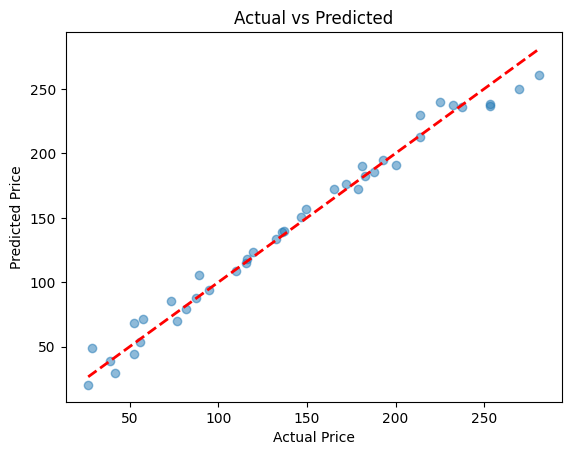

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ("enocder", OneHotEncoder(sparse_output=False), categorical_features),
        ("scaler", StandardScaler(), numerical_features)
    ]
)

pipe = Pipeline([
    ('prep', preprocess),
    ("model", LinearRegression())
])

pipe.fit(X_train, y_train)
model_prediction = pipe.predict(X_test)

r_score = r2_score(y_test, model_prediction)
print(f"The quality of the model: {r_score * 100:.2f}")

mae = mean_absolute_error(y_test, model_prediction)
print(f'On average, my price guess is off by: ${mae:.2f}')

plt.scatter(y_test, model_prediction, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()


RANDOM_FOREST_REGRESSOR

The quality of the model: 98.49
On average, my price guess is off by: $6.85


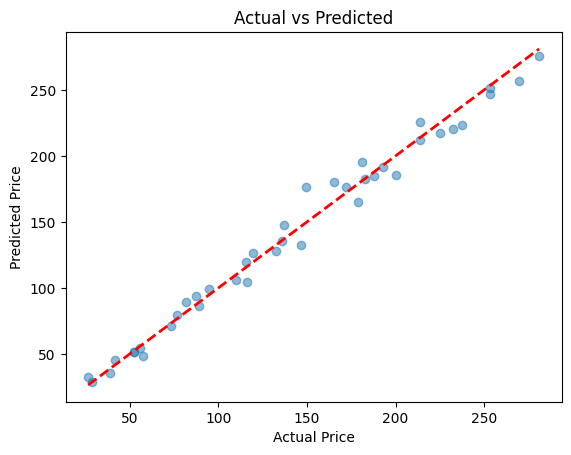

In [7]:
preprocess = ColumnTransformer(
    transformers=[
        ("enocder", OneHotEncoder(sparse_output=False), categorical_features),
        ("scaler", StandardScaler(), numerical_features)
    ]
)

pipe = Pipeline([
    ('prep', preprocess),
    ("model", RandomForestRegressor(random_state=42))
])

model = GridSearchCV(
    estimator=pipe,
    param_grid={
        'model__n_estimators': [20],
        'model__max_depth': [15],
        'model__min_samples_split': [5]
    },
    scoring=['neg_mean_absolute_error', 'r2'],
    refit='neg_mean_absolute_error',
    cv=5
)

model.fit(X_train, y_train)


random_forest_pred = model.predict(X_test)

r_score = r2_score(y_test, random_forest_pred)
print(f"The quality of the model: {r_score * 100:.2f}")

mae = mean_absolute_error(y_test, random_forest_pred)
print(f'On average, my price guess is off by: ${mae:.2f}')

plt.scatter(y_test, random_forest_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()

i scored the model based on the mae and r2 and refitted based on mae because losing money is ba for the company. Over_pricing is losing customers and losing customers is losing money, under pricing is losing revenue which is also bad for the company. Random forest had a lower mae score


GRADIENT_BOOSTING_REGRESSOR

The quality of the model: 97.47
On average, my price guess is off by: $0.09920165921553005


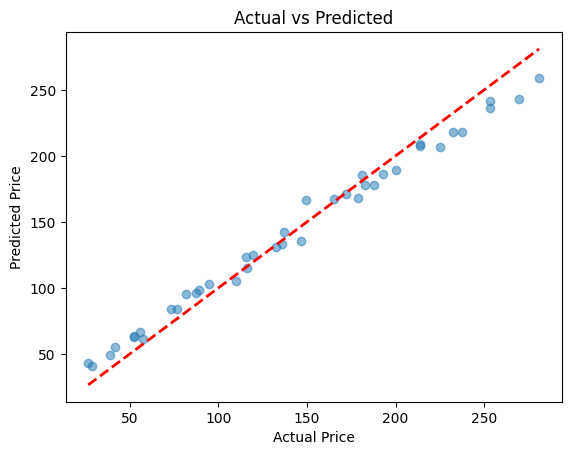

In [ ]:
preprocess = ColumnTransformer(
    transformers=[
        ("enocder", OneHotEncoder(sparse_output=False), categorical_features),
        ("scaler", StandardScaler(), numerical_features)
    ]
)

pipe = Pipeline([
    ('prep', preprocess),
    ("model", GradientBoostingRegressor(random_state=42))
])

model = GridSearchCV(
    estimator=pipe,
    param_grid={
        'model__n_estimators': [20],
        'model__max_depth': [5],
        'model__min_samples_split': [10]
    },
    scoring=['neg_mean_absolute_error', 'r2'],
    refit='neg_mean_absolute_error',
    cv=5
)

model.fit(X_train, y_train)

model_prediction = model.predict(X_test)

r_score = r2_score(y_test, model_prediction)
print(f"The quality of the model: {r_score * 100:.2f}")

mae = mean_absolute_error(y_test, model_prediction)
print(f'On average, my price guess is off by: ${mae}')

plt.scatter(y_test, model_prediction, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted')

plt.show()